## Model a structural connectome

This tutorial will demonstrate how to generate a model structural connectome $G$ using [Normand *et
al.* (2025)](https://www.biorxiv.org/content/10.1101/2025.09.17.676944v5)'s Geometric Eigenmode
Model (GEM),

$$
\displaystyle G_{ij}=\sum_{m=1}^k \frac{\psi_m(i)\psi_m^+(j)}{1+r_s^2\lambda_m},
$$

where:
- $G_{ij}$ denotes the connectivity strength between cortical vertices $i$ and $j$
- $\psi_m(i)$ denotes the amplitude of the $m^{th}$ geometric eigenmode at vertex $i$
- $\lambda_m$ denotes the $m^{th}$ eigenvalue
- $[\ \ ]^+$ denotes the Moore–Penrose pseudoinverse
- $r_s$ denotes the spatial length scale parameter
- $k$ denotes the number of modes used

As in the previous tutorials, we begin by initialising the EigenSolver with a cortical surface and medial wall mask, then solving for the first 120 eigenmodes. To reduce computation and plotting time, we can use the fsLR-4k mesh.

In [8]:
from importlib.resources import files, as_file
import matplotlib.pyplot as plt
from nsbutils.plotting import plot_surf
from neuromodes import EigenSolver
from neuromodes.io import fetch_example_surf
from neuromodes.stats import meanw

mesh, medmask = fetch_example_surf(density='4k', hemi='R')
solver = EigenSolver(mesh, mask=medmask).solve(120)

We can then call the `compute_gem` class method:

In [9]:
G = solver.compute_gem()

Note that $r_s=9.53$ and $k=108$ are used by default, in line with the paper.

We can now visualise the structural connectivity matrix:

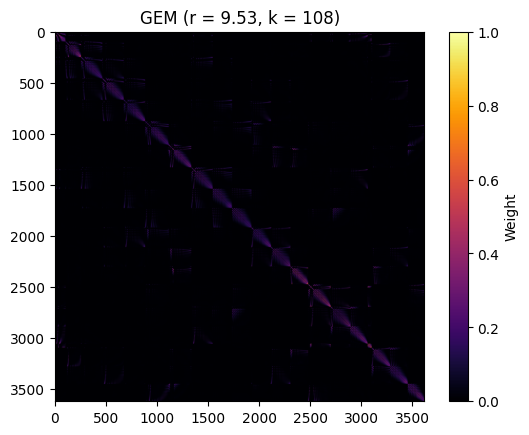

In [14]:
plt.imshow(G, cmap='inferno')
plt.colorbar(label='Weight')
plt.title('GEM (r = 9.53, k = 108)')
plt.show()

We can also visualise the vertex-averaged connectivity on the cortical surface, this time using
 `plot_surf` from our sister package `nsbutils`:

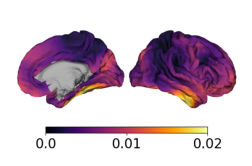

In [15]:
# Area-weighted mean of each vertex's connections to all other vertices
vertex_sc = meanw(G, solver.mass)

# Path to surface
rh_surfpath = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-4k_hemi-R_midthickness.surf.gii'

with as_file(rh_surfpath) as rh_surfpath: 
    plot_surf(
        rh_surfpath,
        solver.unmask_data(vertex_sc),
        cmap='inferno',
        cbar=True
    )

To explore the model further, we can generate another connectome but only use 5 modes instead of the default 108:

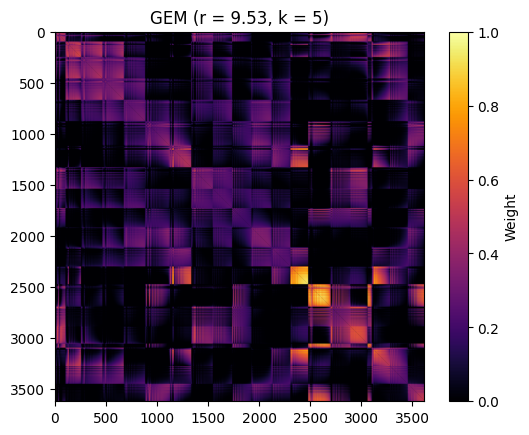

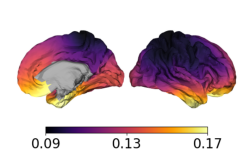

In [16]:
G_k5 = solver.compute_gem(k=5)

plt.imshow(G_k5, cmap='inferno')
plt.colorbar(label='Weight')
plt.title('GEM (r = 9.53, k = 5)')
plt.show()

# Vertex SC
vertex_sc_k5 = meanw(G_k5, solver.mass)

with as_file(rh_surfpath) as rh_surfpath: 
    plot_surf(
        rh_surfpath,
        solver.unmask_data(vertex_sc_k5),
        cmap='inferno',
        cbar=True
    )

What about if we instead increase the spatial length scale parameter from 9.53 to 95.3?

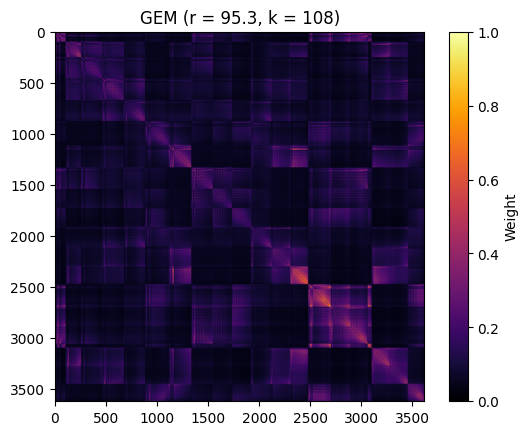

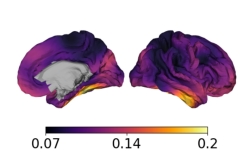

In [17]:
G_r95 = solver.compute_gem(r=95.3)

plt.imshow(G_r95, cmap='inferno')
plt.colorbar(label='Weight')
plt.title('GEM (r = 95.3, k = 108)')
plt.show()

# Vertex SC
vertex_sc_r95 = meanw(G_r95, solver.mass)

with as_file(rh_surfpath) as rh_surfpath: 
    plot_surf(
        rh_surfpath,
        solver.unmask_data(vertex_sc_r95),
        cmap='inferno',
        cbar=True
    )